In [2]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

(7043, 21)

In [3]:
# Check for non-numeric values in TotalCharges
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [4]:
import sys
sys.path.append('../app')

from preprocessing import clean_total_charges

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")  # fresh load, unmodified
df = clean_total_charges(df)

df['TotalCharges'].isna().sum()          # should print 0
df[df['tenure'] == 0][['tenure', 'TotalCharges']]   # should show 0.0, not blank

,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0
3331,0,0.0
3826,0,0.0
4380,0,0.0
5218,0,0.0
6670,0,0.0


In [5]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')  # not a feature

for col in categorical_cols:
    print(col, '->', df[col].unique())

gender -> <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner -> <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents -> <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService -> <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines -> <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService -> <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity -> <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup -> <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection -> <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport -> <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV -> <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies -> <ArrowStringArray>
['No', 'Yes', 'No internet serv

C:\Users\HELLO\AppData\Local\Temp\ipykernel_1980\66293149.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [6]:
import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import (
    clean_total_charges,
    encode_binary_columns,
    collapse_service_columns,
    one_hot_encode_multi_category,
)

In [7]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = clean_total_charges(df)
df = encode_binary_columns(df)
df = collapse_service_columns(df)
df = one_hot_encode_multi_category(df)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   str    
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   MultipleLines                          7043 non-null   int64  
 8   OnlineSecurity                         7043 non-null   int64  
 9   OnlineBackup                           7043 non-null   int64  
 10  DeviceProtection                       7043 non-null   int64  
 11  TechSupport    

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,29.85,29.85,0,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,53.85,108.15,1,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


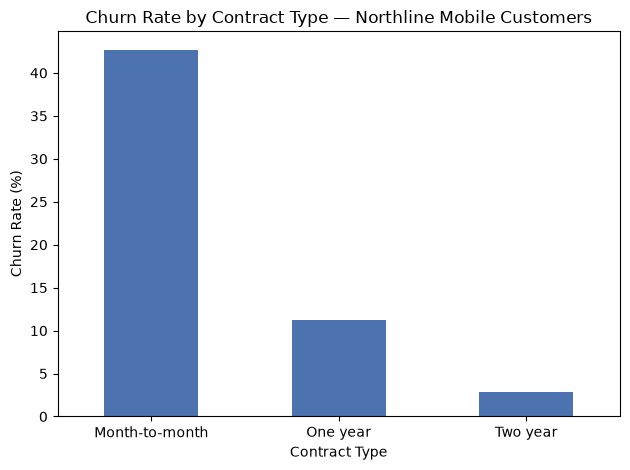

In [8]:
import matplotlib.pyplot as plt

# use the pre-encoded df (before one-hot) so labels are readable
df_raw = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

churn_by_contract = df_raw.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

churn_by_contract.plot(kind='bar', color='#4C72B0')
plt.title('Churn Rate by Contract Type — Northline Mobile Customers')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../notebooks/churn_by_contract.png', dpi=150)
plt.show()

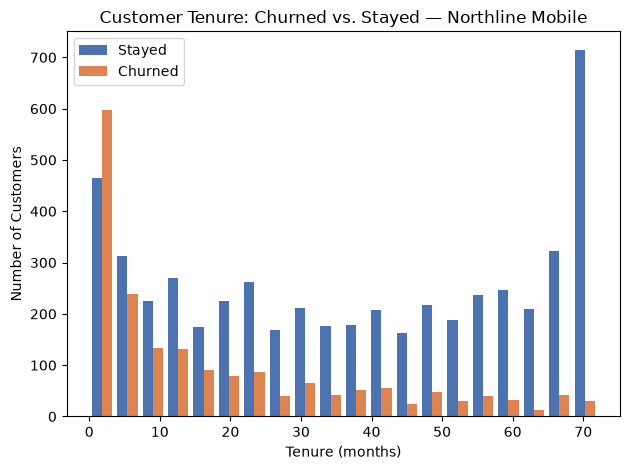

In [9]:
churned = df_raw[df_raw['Churn'] == 'Yes']['tenure']
stayed = df_raw[df_raw['Churn'] == 'No']['tenure']

plt.hist([stayed, churned], bins=20, label=['Stayed', 'Churned'], color=['#4C72B0', '#DD8452'])
plt.title('Customer Tenure: Churned vs. Stayed — Northline Mobile')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/tenure_distribution.png', dpi=150)
plt.show()

In [10]:
# drop the identifier, separate features from target
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5634, 23), (1409, 23))

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



C:\Users\HELLO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


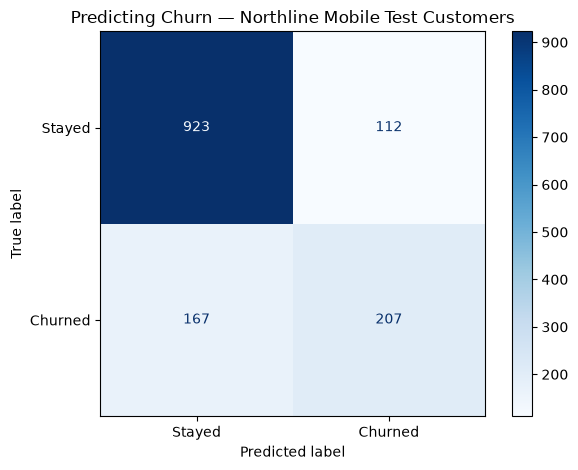

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=['Stayed', 'Churned'],
    cmap='Blues'
)
plt.title('Predicting Churn — Northline Mobile Test Customers')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=150)
plt.show()

In [13]:
import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import scale_numeric_features

X_train, scaler = scale_numeric_features(X_train)
X_test, _ = scale_numeric_features(X_test, scaler=scaler)  # reuse the same scaler, don't refit

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [14]:
import joblib

joblib.dump(model, '../models/churn_pipeline.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X_train.columns), '../models/feature_columns.pkl')

['../models/feature_columns.pkl']

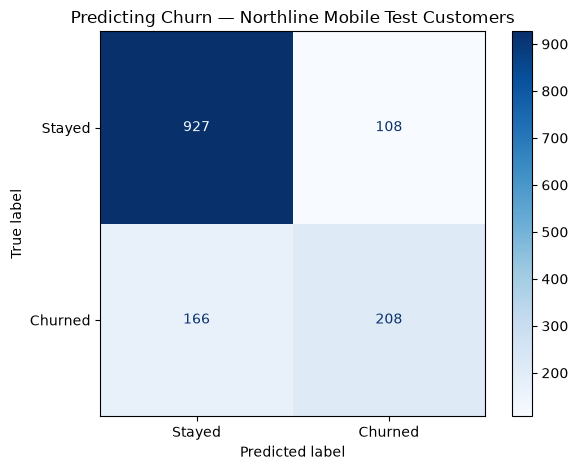

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=['Stayed', 'Churned'],
    cmap='Blues'
)
plt.title('Predicting Churn — Northline Mobile Test Customers')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=150)
plt.show()

In [16]:
import sys
sys.path.append('../app')

import importlib
import preprocessing, model
importlib.reload(preprocessing)
importlib.reload(model)

from model import predict_churn

test_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No",
    "tenure": 12, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "Yes",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "No", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 75.5, "TotalCharges": 890.5
}

predict_churn(test_customer)

{'churn_probability': 0.3136, 'prediction': 0, 'risk_level': 'Medium'}